In [53]:
import pandas as pd

# Step 1: File paths
file_paths = [
    'C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/Bot/Bot_data.csv',
    'C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/Bruteforce/BruteForceAttack_data.csv',
    'C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/DDoS/DDoS_data.csv',
    'C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/DDoShulk/DDoShulk_data.csv',
    'C:/Users/saipr/OneDrive/Documents/Deep Learning/FL-IDS Project/Portscan/Portscan_data.csv'
]

# Step 2: Read and merge all
df_list = []
for path in file_paths:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()              # Clean column names
    df.rename(columns={df.columns[-1]: 'Label'}, inplace=True)  # Rename last col to 'Label'
    df['Label'] = df['Label'].apply(lambda x: 0 if str(x).strip().lower() == 'benign' else 1)
    df_list.append(df)

# Step 3: Concatenate all
merged_df = pd.concat(df_list, ignore_index=True)

# Step 4: Check result
print("Label Distribution After Binary Conversion:")
print(merged_df['Label'].value_counts())
print("Dataset Shape:", merged_df.shape)


Label Distribution After Binary Conversion:
Label
0    1022539
1     543775
Name: count, dtype: int64
Dataset Shape: (1566314, 79)


In [9]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install pandas numpy


Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [55]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Step 1: Separate features and target
X = merged_df.drop(columns=['Label'])
y = merged_df['Label']

# Step 2: Keep only numerical columns
X = X.select_dtypes(include=[np.number])

# Step 3: Replace inf/-inf with NaN, drop rows with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = y.loc[X.index]  # Keep labels in sync with X

# Step 4: Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Convert to DataFrame
X_df = pd.DataFrame(X_scaled, columns=X.columns)
y_df = y.reset_index(drop=True)

# Step 6: Combine into one final DataFrame
final_df = pd.concat([X_df, y_df], axis=1)

# Check status
print("Preprocessing Complete")
print("Final shape:", final_df.shape)
print("Label distribution:\n", y_df.value_counts())

Preprocessing Complete
Final shape: (1564355, 79)
Label distribution:
 Label
0    1021667
1     542688
Name: count, dtype: int64


In [57]:
from sklearn.feature_selection import SelectKBest, f_classif

# Step 1: Select top 25 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=25)
X_selected = selector.fit_transform(X_df, y_df)

# Step 2: Get selected feature names
selected_mask = selector.get_support()
selected_feature_names = X_df.columns[selected_mask]
print("Top 25 Selected Features:\n", list(selected_feature_names))

# Step 3: Create DataFrame with selected features only
X_selected_df = X_df[selected_feature_names].copy()

# Step 4: Combine with target column
final_selected_df = pd.concat([X_selected_df, y_df], axis=1)

# Optional: Shape and peek
print("Final selected dataset shape:", final_selected_df.shape)
print(final_selected_df.head())

C:\Users\saipr\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [31 32 33 49 56 57 58 59 60 61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\saipr\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 25 Selected Features:
 ['Destination Port', 'Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd IAT Max', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'URG Flag Count', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min']
Final selected dataset shape: (1564355, 26)
   Destination Port  Flow Duration  Bwd Packet Length Max  \
0         -0.219308       2.565638              -0.484247   
1         -0.391275       2.565634              -0.384508   
2         -0.414511       2.593318              -0.513678   
3         -0.094648      -0.501167              -0.513678   
4         -0.414511      -0.502402              -0.513678   

   Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  \
0  

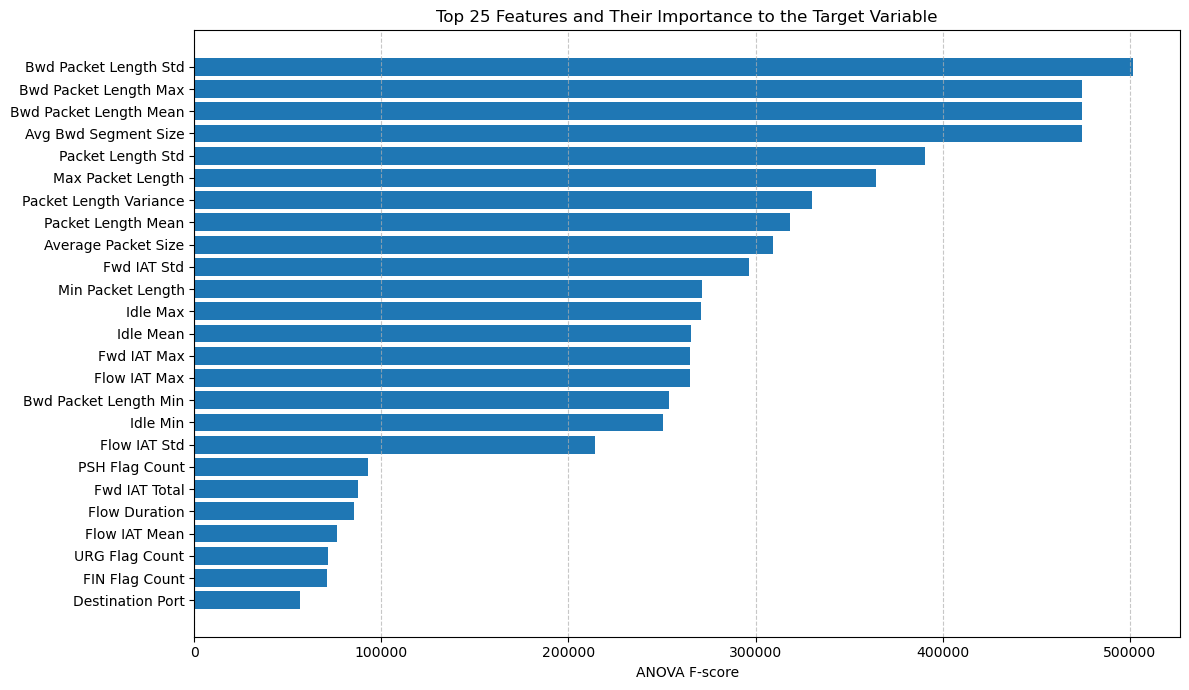

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Get F-scores and feature names for selected 25
feature_scores = selector.scores_
selected_mask = selector.get_support()

selected_names = np.array(X_df.columns[selected_mask])
selected_scores = np.array(feature_scores[selected_mask])

# Sort by score
sorted_idx = np.argsort(selected_scores)[::-1]
sorted_names = selected_names[sorted_idx]
sorted_scores = selected_scores[sorted_idx]

# Plot
plt.figure(figsize=(12, 7))
plt.barh(sorted_names[::-1], sorted_scores[::-1])
plt.xlabel("ANOVA F-score")
plt.title("Top 25 Features and Their Importance to the Target Variable")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
# Step 1: Shuffle the dataset
final_selected_df = final_selected_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 2: Split into 3 equal parts (clients)
total_rows = final_selected_df.shape[0]
part_size = total_rows // 3

client1_df = final_selected_df.iloc[:part_size]
client2_df = final_selected_df.iloc[part_size:2*part_size]
client3_df = final_selected_df.iloc[2*part_size:]

# Optional: Confirm shape and label balance
print("Client 1 shape:", client1_df.shape)
print("Client 2 shape:", client2_df.shape)
print("Client 3 shape:", client3_df.shape)

print("Label distribution:")
print("Client 1:\n", client1_df['Label'].value_counts())
print("Client 2:\n", client2_df['Label'].value_counts())
print("Client 3:\n", client3_df['Label'].value_counts())

Client 1 shape: (521451, 26)
Client 2 shape: (521451, 26)
Client 3 shape: (521453, 26)
Label distribution:
Client 1:
 Label
0    340906
1    180545
Name: count, dtype: int64
Client 2:
 Label
0    340633
1    180818
Name: count, dtype: int64
Client 3:
 Label
0    340128
1    181325
Name: count, dtype: int64


In [65]:
client1_df.to_csv("client1_data.csv", index=False)
client2_df.to_csv("client2_data.csv", index=False)
client3_df.to_csv("client3_data.csv", index=False)

print("Client datasets saved as CSV files.")

Client datasets saved as CSV files.


In [67]:
print(os.getcwd())

C:\Users\saipr
